#  Generative AI Model (VAE) to Predict Gene Expression from Drug SMILES (Part I)

### Project Introduction

This project tackles a core challenge in drug discovery: predicting how a drug will affect a cell's biology before it's ever tested in the lab. 
```
Gene Expression Change = f(Drug, Cell Type)
```
We use the LINCS L1000 (GSE92742) dataset, because it is the gold-standard, largest, and most comprehensive public resource designed for exactly this project's goal: predicting how a cell's gene expression changes in response to a drug. The dataset contains each variable in the equation above:

  * **Gene Expression Change**: It contains the gene expression changes (the Z-scores in the .gctx file).

  * **Drug**: It tells you which drug was used for each experiment (in the sig_info and pert_info files).

  * **Cell Type**: It tells you which cell type was used (also in the sig_info file)

This project aims to build and refine a Conditional Variational Autoencoder (CVAE) to predict how a drug's chemical structure will alter gene expression in cells. By training on a large dataset of known drug effects, the model learns a compressed, meaningful "latent space" that represents the complex biological responses to different compounds. 

The ultimate goal is not just to reconstruct existing data accurately but to use this learned understanding to generate plausible gene expression profiles for entirely new, unseen drugs, a key task in modern drug discovery. The process involves a semi-supervised approach, incorporating a classifier to predict a drug's mechanism of action (MoA) to better organize this latent space. 

This project is broken into two parts:

* **Part I** (This Notebook): This phase is comprised of exploratory data analysis, definition of the data ingestion pipeline and model training.

* **Part II**: This phase builds on the first phase to optimize the cVAE to ensure that the model is generating biologically relevant data by iterating and validating the model against Gene Set Enrichment Analysis.


--- 
### References

**Data Sources and Platforms**

* [LINCS L1000 (GSE92742)](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742): The data used here is the LINCS L1000 - the gold-standard, largest and most comprehensive public resource designed for predicting how a cell's gene expression changes in response to a drug.

* [Broad Institute's Drug Repurposing Hub](https://repo-hub.broadinstitute.org/repurposing#download-data): This data contains the Mechanism of Action (MoA)for each compound in the LINCS L1000 dataset, primarily curated and maintained by the Broad Institute through resources like the Drug Repurposing Hub.

**Libraries**
* [RDKit](https://www.rdkit.org/docs/#): Open-source cheminformatics toolkit widely used for computational chemistry and drug discovery. It provides a powerful suite of tools for working with chemical structures, including methods for reading and writing molecular file formats, generating 2D and 3D molecular representations, and calculating chemical descriptors and fingerprints

---
### Table of Contents

1. [Imports](#imports)
2. [Constants & Data Import](#constants-&-data-import)
3. [Utility Functions](#utility-functions)
4. [Data Exploration](#data-exploration)
5. [Feature Engineering](#feature-engineering)
6. [Train the Model](#train-the-model) 
7. [Summary](#summary)

---
### 1. Imports <a class="anchor" id="imports"></a>

In [1]:
import os
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Any
from tqdm import tqdm

import wandb
import imageio

import yaml
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [2]:
if torch.cuda.is_available():
    print("✅ Success! PyTorch can see the GPU.")
    print(f"Device: {torch.cuda.get_device_name(0)}")
else:
    print("❌ Installation failed. PyTorch cannot see the GPU.")

✅ Success! PyTorch can see the GPU.
Device: Tesla V100-SXM2-16GB


Local Imports

In [3]:
from drug_induced_gene_expression_prediction import (
    LincsDataset,
    CVAE,
    vae_loss_function,
    evaluate_recon_and_gen_gsea_for_pert,
    plot_training_history,
    get_recon_correlation,
)

---
### 2. Constants & Data Import <a class="anchor" id="constants"></a>


The necessary data files can be accessed and downloaded via the [Gene Expression Omnibus Portal](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742). The following specific datasets are required:

* **The Gene Expression Data**

    *GSE92742_Broad_LINCS_Level5_COMPZ.MODZ_n473647x12328.gctx.gz* 
    
    The main data matrix that contains the results of nearly half a million experiments (how much a gene's expression went up or down in a single experiment compared to a control)

* **The Signature Info File**

    *GSE92742_Broad_LINCS_sig_info.txt*

    Metadata file that explains what each column in the expression matrix means.

* **The Perturbation Info File**

    *GSE92742_Broad_LINCS_pert_info.txt*

    The drug dictionary that provides details about the perturbations used in the experiments.

* **The Gene Info File**

    *GSE92742_Broad_LINCS_gene_info.txt*

    The gene dictionary that provides details about the genes measured.


The notebook expects both tsv files to be placed in the `data/LINCS_L1000` folder.

In [4]:
ROOT = Path(os.getcwd()).parents[1]

PROCESSED_DATA_PATH = os.path.join(
    ROOT, "data", "processed", "drug_induced_gene_expression_prediction"
)

df_train = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "train_data.parquet"))
df_val = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "val_data.parquet"))
df_test = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "test_data.parquet"))

df_meta_train = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "train_meta.parquet"))
df_meta_val = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "val_meta.parquet"))
df_meta_test = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "test_meta.parquet"))

# load the gene mapping
df_gene_mapping = pd.read_parquet(
    os.path.join(PROCESSED_DATA_PATH, "gene_mapping.parquet")
)

# Load the int_to_moa mapping
with open(os.path.join(PROCESSED_DATA_PATH, "int_to_moa.yaml"), "r") as f:
    int_to_moa = yaml.safe_load(f)

---
### 3. Utility Functions <a class="anchor" id="utility"></a>

In [5]:
def plot_pca(
    embeddings: np.ndarray, labels: pd.Series, title: str = "PCA Plot", axes=None
) -> None:
    """
    Plot PCA embeddings with color-coded labels.

    Args:
        embeddings (np.ndarray): embeddings.
        labels (pd.Series): Labels for coloring the points.
        title (str): Title of the plot.
        axes (plt.Axes, optional): Axes to plot on. If None, creates a new figure.
    """
    scaler = StandardScaler()
    embeddings = scaler.fit_transform(embeddings)

    if axes is None:
        _, axes = plt.subplots(figsize=(8, 6))

    # Encode labels for coloring
    le = LabelEncoder()
    label_ids = le.fit_transform(labels)

    pca_model = PCA(n_components=2, random_state=42)
    embedding = pca_model.fit_transform(embeddings)
    # Plot
    scatter = axes.scatter(
        embedding[:, 0], embedding[:, 1], c=label_ids, cmap="tab10", s=40
    )
    axes.set_title(title)
    # Fix legend for UMAP plot with multiple classes
    handles, _ = scatter.legend_elements()
    axes.legend(
        handles=handles,
        labels=list(le.classes_),
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )
    plt.tight_layout()

    return axes


def generate_embeddings(model, dataset, df_meta_data, device, batch_size):
    """
    Generate latent embeddings (mu) and labels for a given dataset.
    """
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        # for condition, expression, moa_label in loader:
        meta_batches = [df_meta_data.iloc[i:i+batch_size] for i in range(0, len(df_meta_data), batch_size)]
        expression_batches = [dataset.df_expression.iloc[i:i+batch_size] for i in range(0, len(dataset.df_expression), batch_size)]

        for meta_batch, expression_batch in zip(meta_batches, expression_batches):
            conditions = torch.tensor(np.stack(meta_batch["fingerprint"].values)).to(device)
            # moa_labels = torch.tensor(meta_batch["pert_id"].values).to(device)
            moa_labels = torch.tensor(meta_batch["moa_int"].values).to(device)
            expressions = torch.tensor(expression_batch.values).to(device)

            # Forward pass
            _, mu, _ = model(expressions, conditions)

            all_embeddings.append(mu.cpu().numpy())
            all_labels.append(moa_labels.cpu().numpy())


    # Concatenate all batches
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_moa_labels = [int_to_moa[label] for label in all_labels]
    return all_embeddings, all_labels, all_moa_labels, 


---
### 4. Modeling <a class="anchor" id="modelin"></a>

In [6]:
BATCH_SIZE = 8

train_dataset = LincsDataset(df_train, df_meta_train)
val_dataset = LincsDataset(df_val, df_meta_val)
test_dataset = LincsDataset(df_test, df_meta_test)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
df_train.shape, df_val.shape, df_test.shape

((4592, 12328), (1149, 12328), (315, 12328))

In [8]:
print(len(train_loader))

574


#### Load Model Parameters

Load the configuration file that contains the model parameters for easy experiment tracking.  Initialize and visualize the model archetecture.

In [9]:
# read in training config
with open(
    os.path.join(ROOT, "config", "drug_induced_gene_expression_prediction.yaml"), "r"
) as file:
    config = yaml.safe_load(file)

# # Initialize the CVAE model
model = CVAE(
    expression_dim=df_train.shape[1],  # Number of genes
    num_classes=df_meta_train[
        "moa_int"
    ].nunique(),  # Number of MOA classes + 1 for "Other"
    condition_dim=df_meta_train["fingerprint"].iloc[0].shape[0],  # Fingerprint size
    hidden_dim=config["hidden_dim"],  # Hidden dimension for the encoder and decoder
    latent_dim=config["latent_dim"],  # Latent space dimension
    num_encoder_layers=config["num_encoder_layers"],  # Number of layers in the encoder
    encoder_dropout_rate=config["encoder_dropout"],  # Dropout rate for the encoder
    num_decoder_layers=config["num_decoder_layers"],  # Number of layers in the decoder
    condition_emb_dim=config[
        "condition_emb_dim"
    ],  # Embedding dimension for the condition (fingerprint)
    decoder_dropout_rate=config["decoder_dropout"],  # Dropout rate for the decoder
    num_molecular_emb_layers=config[
        "num_molecular_emb_layers"
    ],  # Number of layers in the molecular embedding
)

model = model.to("cuda" if torch.cuda.is_available() else "cpu")

print(model)

CVAE(
  (molecular_embedding): MolecularEmbedding(
    (fc_initial): Linear(in_features=2048, out_features=5632, bias=True)
    (fc_layers): ModuleList(
      (0): Linear(in_features=5632, out_features=5120, bias=True)
      (1): Linear(in_features=5120, out_features=4608, bias=True)
      (2): Linear(in_features=4608, out_features=4096, bias=True)
      (3): Linear(in_features=4096, out_features=3584, bias=True)
      (4): Linear(in_features=3584, out_features=3072, bias=True)
      (5): Linear(in_features=3072, out_features=2560, bias=True)
      (6): Linear(in_features=2560, out_features=2048, bias=True)
      (7): Linear(in_features=2048, out_features=1536, bias=True)
      (8): Linear(in_features=1536, out_features=1024, bias=True)
      (9): Linear(in_features=1024, out_features=512, bias=True)
    )
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (classification_head): ClassificationHead(
    (fc_initial): Linear(in_features=32, out_features=23, bias=True)
    (dropout): Drop

#### Get Pre-Trained Model Embeddings

/var/tmp/ipykernel_29455/3781794211.py:32: UserWarning: Mismatched number of handles and labels: len(handles) = 8 len(labels) = 20
  axes.legend(


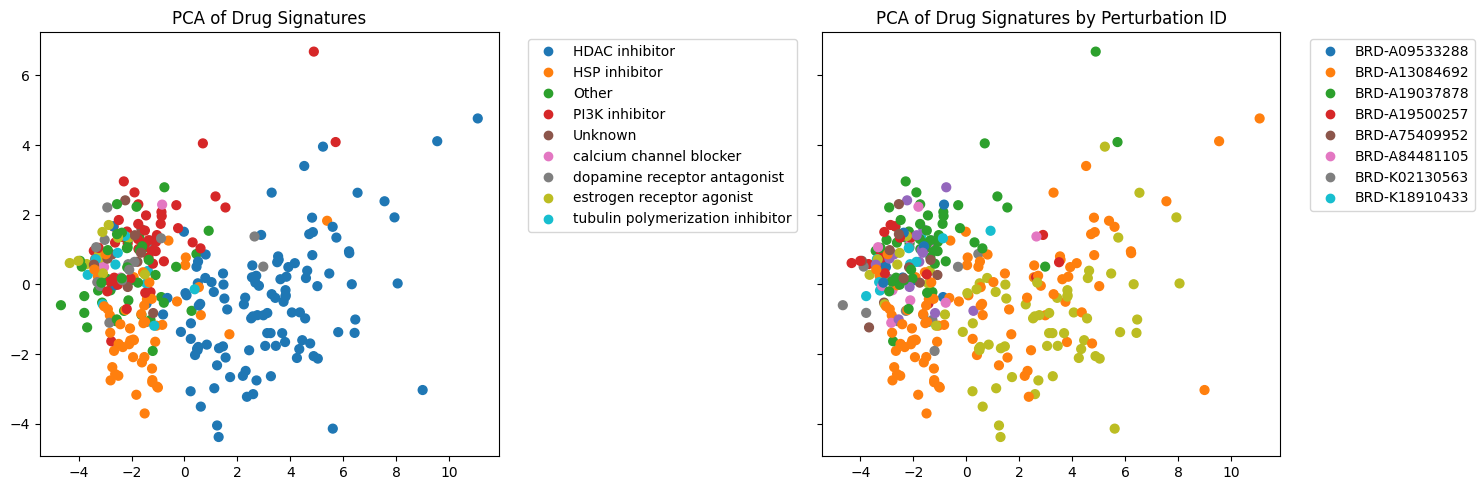

In [10]:
embeddings, labels, all_moa_labels = generate_embeddings(
    model,
    test_dataset,
    df_meta_test,
    batch_size=BATCH_SIZE,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

_, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
plot_pca(
    embeddings, all_moa_labels, title="PCA of Drug Signatures", axes=axes[0]
)
plot_pca(
    embeddings,
    df_meta_test["pert_id"],
    title="PCA of Drug Signatures by Perturbation ID",
    axes=axes[1],
);

In [11]:
from matplotlib.lines import Line2D
import seaborn as sns

def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    config: Dict[str, Any],
    beta: float,
    device: torch.device,
) -> Dict[str, float]:
    """Runs a single training epoch."""
    model.train()
    total_loss, total_recon, total_kl, total_class = 0, 0, 0, 0

    for condition, expression, moa_label in loader:
        expression, condition, moa_label = (
            expression.to(device),
            condition.to(device),
            moa_label.to(device),
        )

        optimizer.zero_grad()
        recon_x, mu, log_var = model(expression, condition)
        moa_prediction = model.classify(mu)

        # Calculate VAE and classification loss
        loss, recon, kl = vae_loss_function(
            recon_x,
            expression,
            mu,
            log_var,
            model.latent_dim,
            beta,
            recon_weight=config["alpha"],
        )
        mask = moa_label != -1
        class_loss = torch.tensor(0.0, device=device)
        if mask.sum() > 0:
            class_loss = nn.functional.cross_entropy(
                moa_prediction[mask], moa_label[mask]
            )

        total_epoch_loss = loss + config["gamma"] * class_loss
        total_epoch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += total_epoch_loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        total_class += class_loss.item()

    # Return average losses for the epoch
    return {
        "loss": total_loss / len(loader),
        "recon": total_recon / len(loader),
        "kl": total_kl / len(loader),
        "class_loss": total_class / len(loader),
    }


def evaluate_epoch(
    model: nn.Module,
    loader: DataLoader,
    config: Dict[str, Any],
    beta: float,
    device: torch.device,
) -> Dict[str, float]:
    """Runs a single validation/evaluation epoch."""
    model.eval()
    total_loss, total_recon, total_kl, total_class = 0, 0, 0, 0

    with torch.no_grad():
        for condition, expression, moa_label in loader:
            expression, condition, moa_label = (
                expression.to(device),
                condition.to(device),
                moa_label.to(device),
            )
            recon_x, mu, log_var = model(expression, condition)
            moa_prediction = model.classify(mu)

            loss, recon, kl = vae_loss_function(
                recon_x,
                expression,
                mu,
                log_var,
                model.latent_dim,
                beta,
                recon_weight=config["alpha"],
            )
            mask = moa_label != -1
            class_loss = torch.tensor(0.0, device=device)
            if mask.sum() > 0:
                class_loss = nn.functional.cross_entropy(
                    moa_prediction[mask], moa_label[mask]
                )

            total_epoch_loss = loss + config["gamma"] * class_loss

            total_loss += total_epoch_loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            total_class += class_loss.item()

    return {
        "loss": total_loss / len(loader),
        "recon": total_recon / len(loader),
        "kl": total_kl / len(loader),
        "class_loss": total_class / len(loader),
    }


def create_animation_frames(
    epoch_history: list,
    animation_dir: str,
) -> list:
    """Creates PCA plots for each epoch and saves them as frames."""
    print("Generating animation frames...")
    # Fit PCA on the final epoch's embeddings for a stable projection
    final_embeddings = epoch_history[-1]["embeddings"]
    pca = PCA(n_components=2, random_state=42)
    pca.fit(final_embeddings)

    frame_files = []
    all_embeddings = []
    for i, epoch_data in enumerate(epoch_history):
        # Use the SAME fitted PCA to transform embeddings from every epoch
        projected_embeddings = pca.transform(epoch_data["embeddings"])
        all_embeddings.append(projected_embeddings)

    stacked_embeddings = np.concatenate(all_embeddings, axis=0)
    x_lim = (stacked_embeddings[:, 0].min() - 1, stacked_embeddings[:, 0].max() + 1)
    y_lim = (stacked_embeddings[:, 1].min() - 1, stacked_embeddings[:, 1].max() + 1)
    
    labels_for_legend = epoch_history[0]["pert_labels"]
    unique_labels = np.unique(labels_for_legend)
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i) for i in np.linspace(0, 1, len(unique_labels))]

    legend_elements_pert = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=f"Class {label}",
            markerfacecolor=color,
            markersize=8,
            linewidth=0,
            alpha=0.7,
        )
        for label, color in zip(unique_labels, colors)
    ]

    labels_for_legend = epoch_history[0]["labels"]
    unique_labels = np.unique(labels_for_legend)
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in np.linspace(0, 1, len(unique_labels))]

    legend_elements_ids = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=f"Class {label}",
            markerfacecolor=color,
            markersize=8,
            linewidth=0,
            alpha=0.7,
        )
        for label, color in zip(unique_labels, colors)
    ]

    for i, epoch_data in enumerate(epoch_history):
        epoch_num = i + 1

        fig, ax = plt.subplots(1, 2, figsize=(10, 8), sharex=True, sharey=True)

        sns.scatterplot(
            x=all_embeddings[i][:, 0],
            y=all_embeddings[i][:, 1],
            hue=df_meta_test["pert_id"].tolist(),
            palette="tab20",
            s=40,
            alpha=0.5,
            ax=ax[0],
        )
        ax[0].set_title(f"Latent Space PCA - Epoch {epoch_num}")
        ax[0].set_xlabel("PCA Component 1")
        ax[0].set_ylabel("PCA Component 2")
        ax[0].set_xlim(x_lim)
        ax[0].set_ylim(y_lim)

        # Add legend
        ax[0].legend(
            handles=legend_elements_pert,
            title="Classes",
            fontsize=12,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
        )
        ax[0].set_aspect("equal", adjustable="box")
        
        sns.scatterplot(
            x=all_embeddings[i][:, 0],
            y=all_embeddings[i][:, 1],
            hue=df_meta_test["pert_id"].tolist(),
            palette="tab10",
            s=40,
            alpha=0.5,
            ax=ax[1],
        )
        ax[1].set_title(f"Latent Space PCA - Epoch {epoch_num}")
        ax[1].set_xlabel("PCA Component 1")
        ax[1].set_ylabel("PCA Component 2")
        ax[1].set_xlim(x_lim)

        # Add legend
        ax[1].legend(
            handles=legend_elements_ids,
            title="Classes",
            fontsize=12,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
        )
        ax[1].set_aspect("equal", adjustable="box")
        
        # Save the frame
        frame_path = os.path.join(animation_dir, f"epoch_{epoch_num:03d}.png")
        plt.savefig(frame_path, bbox_inches="tight", dpi=100)
        plt.close(fig)
        frame_files.append(frame_path)

    return frame_files


def build_animation_gif(
    frame_files: list,
    output_path: str,
    duration: float = 0.5,
):
    """Builds a GIF from a list of frame files."""
    print("Creating animation...")
    with imageio.get_writer(output_path, mode="I", duration=duration) as writer:
        for filename in frame_files:
            image = imageio.imread(filename)
            writer.append_data(image)
    print(f"Animation saved to {output_path}")


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    df_meta_test: pd.DataFrame,
    config: Dict[str, Any],
    device: torch.device,
) -> Tuple[nn.Module, Dict[str, list]]:
    """
    Main orchestrator for training the model, logging, and creating an animation.
    """
    run_name = f"cvae_model_{config['latent_dim']}latent_{config['hidden_dim']}hidden"
    animation_dir = os.path.join(ROOT, "imgs", run_name, "animation_frames")
    os.makedirs(animation_dir, exist_ok=True)

    wandb.init(
        project="drug-induced-gene-expression-prediction", config=config, name=run_name
    )
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["learning_rate"], weight_decay=1e-5
    )
    model.to(device)

    history = {
        k: []
        for k in [
            "train_loss",
            "val_loss",
            "train_recon",
            "val_recon",
            "train_kl",
            "val_kl",
            "train_class_loss",
            "val_class_loss",
        ]
    }
    animation_data = []

    # Main Training Loop
    pbar_epochs = tqdm(range(1, config["num_epochs"] + 1), desc="Overall Progress")
    for epoch in pbar_epochs:
        beta = (
            config["beta"] * ((epoch - 1) / config["num_epochs"])
            if config.get("beta_anneal")
            else config["beta"]
        )

        train_metrics = train_epoch(
            model, train_loader, optimizer, config, beta, device
        )
        val_metrics = evaluate_epoch(model, val_loader, config, beta, device)

        for key in train_metrics:
            history[f"train_{key}"].append(train_metrics[key])
            history[f"val_{key}"].append(val_metrics[key])

        wandb.log(
            {
                "Train Loss": train_metrics["loss"],
                "Val Loss": val_metrics["loss"],
                "Train Recon": train_metrics["recon"],
                "Val Recon": val_metrics["recon"],
                "Train KL": train_metrics["kl"],
                "Val KL": val_metrics["kl"],
                "Train Class Loss": train_metrics["class_loss"],
                "Val Class Loss": val_metrics["class_loss"],
                "Beta": beta,
                "Epoch": epoch,
            },
            step=epoch,
        )

        # Generate and store data for animation
        test_embeddings, test_labels, _ = generate_embeddings(model, test_loader.dataset, df_meta_test, batch_size=test_loader.batch_size, device=device)
        animation_data.append({"embeddings": test_embeddings, "labels": test_labels, "pert_labels": df_meta_test["pert_id"].tolist()})
        pbar_epochs.set_postfix(
            {
                "Train Loss": f"{train_metrics['loss']:.4f}",
                "Val Loss": f"{val_metrics['loss']:.4f}",
            }
        )

    # Create and Log Animation
    frame_files = create_animation_frames(animation_data, animation_dir)
    animation_path = os.path.join(ROOT, "imgs", run_name, "training_animation.gif")
    build_animation_gif(frame_files, animation_path, duration=0.5)
    wandb.log({"training_animation": wandb.Video(animation_path, fps=2, format="gif")})

    # Cleanup and Return
    wandb.finish()
    return model, history

In [ ]:
model, history = train_model(
    model, train_loader, val_loader, test_loader, df_meta_test, config, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

wandb: Currently logged in as: dantrainer01 (dantrainer01-none) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Overall Progress:   2%|▏         | 1/50 [00:38<31:25, 38.47s/it, Train Loss=3965.8860, Val Loss=3016.7289]

#### Visualize the training curves

In [ ]:
embeddings, labels, all_moa_labels = generate_embeddings(
    model,
    test_dataset,
    df_meta_test,
    batch_size=BATCH_SIZE,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

_, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
plot_pca(
    embeddings, all_moa_labels, title="PCA of Drug Signatures", axes=axes[0]
)
plot_pca(
    embeddings,
    df_meta_test["pert_id"],
    title="PCA of Drug Signatures by Perturbation ID",
    axes=axes[1],
);

In [ ]:
embeddings, labels, all_moa_labels = generate_embeddings(
    model,
    val_dataset,
    df_meta_val,
    batch_size=BATCH_SIZE,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

_, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
plot_pca(
    embeddings, all_moa_labels, title="PCA of Drug Signatures", axes=axes[0]
)
plot_pca(
    embeddings,
    df_meta_val["moa_int"],
    title="PCA of Drug Signatures by Perturbation ID",
    axes=axes[1],
);

In [ ]:
plot_training_history(history)

In [ ]:
img_save_path = ROOT
gsea_recon_error, gsea_gen_error = evaluate_recon_and_gen_gsea_for_pert(
    pert_id_to_test="BRD-A00993607",
    val_dataset=val_loader.dataset,
    df_gene_mapping=df_gene_mapping,
    img_save_path=img_save_path,
    model=model,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

train_corr, val_corr = get_recon_correlation(
    model, train_loader, val_loader, img_save_path, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

In [ ]:
# read in training config
with open(
    os.path.join(ROOT, "config", "sweep.yaml"), "r"
) as file:
    sweep_config = yaml.safe_load(file)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sweep_id = wandb.sweep(sweep_config, project="drug_induced_gene_expression_prediction")

def train_with_sweep():
    with wandb.init() as run:
            
        config = wandb.config

        model = CVAE(
            expression_dim=df_train.shape[1],  # Number of genes
            num_classes=df_meta_train[
                "moa_int"
            ].nunique(),  # Number of MOA classes + 1 for "Other"
            condition_dim=df_meta_train["fingerprint"].iloc[0].shape[0],  # Fingerprint size
            hidden_dim=config["hidden_dim"],  # Hidden dimension for the encoder and decoder
            latent_dim=config["latent_dim"],  # Latent space dimension
            num_encoder_layers=config["num_encoder_layers"],  # Number of layers in the encoder
            encoder_dropout_rate=config["encoder_dropout"],  # Dropout rate for the encoder
            num_decoder_layers=config["num_decoder_layers"],  # Number of layers in the decoder
            condition_emb_dim=config[
                "condition_emb_dim"
            ],  # Embedding dimension for the condition (fingerprint)
            decoder_dropout_rate=config["decoder_dropout"],  # Dropout rate for the decoder
            num_molecular_emb_layers=config[
                "num_molecular_emb_layers"
            ],  # Number of layers in the molecular embedding
        )
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model.to(device)

        num_epochs = config["num_epochs"]
        alpha = config["alpha"]  # Reconstruction loss weight
        gamma = config["gamma"]  # Classification loss weight
        beta = config["beta"]  # KL divergence weight

        sweep_name = run.sweep_id
        run_name = run.name
        run_id = run.name.split("-")[-1] 
        img_save_dir = f"{run_id}_{run_name}_cvae_model_{config['latent_dim']}latent_{config['hidden_dim']}hidden_{config['num_encoder_layers']}enclayers_{config['encoder_dropout']:.2f}do_{config['condition_emb_dim']}condembs_{config['learning_rate']:.2f}lr_{config['alpha']:.2f}a_{config['beta']:.2f}b_{config['gamma']:.2f}g_{config['num_molecular_emb_layers']}condlayers_{config['num_decoder_layers']}declayers"
        img_save_path = os.path.join(ROOT, "data", "hyperparameter_runs", sweep_name, img_save_dir)
        animation_save_path = os.path.join(ROOT, "data", "hyperparameter_runs", sweep_name, "animation_frames")

        os.makedirs(animation_save_path, exist_ok=True)
        os.makedirs(img_save_path, exist_ok=True)

        optimizer = torch.optim.Adam(
            model.parameters(), lr=config["learning_rate"], weight_decay=1e-5
        )
        model.to(device)

        history = {
            k: []
            for k in [
                "train_loss",
                "val_loss",
                "train_recon",
                "val_recon",
                "train_kl",
                "val_kl",
                "train_class_loss",
                "val_class_loss",
            ]
        }
        animation_data = []

        # Main Training Loop
        pbar_epochs = tqdm(range(1, config["num_epochs"] + 1), desc="Overall Progress")
        for epoch in pbar_epochs:
            beta = (
                config["beta"] * ((epoch - 1) / config["num_epochs"])
                if config.get("beta_anneal")
                else config["beta"]
            )

            train_metrics = train_epoch(
                model, train_loader, optimizer, config, beta, device
            )
            val_metrics = evaluate_epoch(model, val_loader, config, beta, device)

            for key in train_metrics:
                history[f"train_{key}"].append(train_metrics[key])
                history[f"val_{key}"].append(val_metrics[key])

            wandb.log(
                {
                    "Train Loss": train_metrics["loss"],
                    "Val Loss": val_metrics["loss"],
                    "Train Recon": train_metrics["recon"],
                    "Val Recon": val_metrics["recon"],
                    "Train KL": train_metrics["kl"],
                    "Val KL": val_metrics["kl"],
                    "Train Class Loss": train_metrics["class_loss"],
                    "Val Class Loss": val_metrics["class_loss"],
                    "Beta": beta,
                    "Epoch": epoch,
                },
                step=epoch,
            )

            # Generate and store data for animation
            test_embeddings, test_labels, _ = generate_embeddings(model, test_loader.dataset, df_meta_test, batch_size=test_loader.batch_size, device=device)
            animation_data.append({"embeddings": test_embeddings, "labels": test_labels, "pert_labels": df_meta_test["pert_id"].tolist()})
            pbar_epochs.set_postfix(
                {
                    "Train Loss": f"{train_metrics['loss']:.4f}",
                    "Val Loss": f"{val_metrics['loss']:.4f}",
                }
            )

        gsea_recon_error, gsea_gen_error = evaluate_recon_and_gen_gsea_for_pert(
            pert_id_to_test="BRD-A00993607",
            val_dataset=val_loader.dataset,
            df_gene_mapping=df_gene_mapping,
            img_save_path=img_save_path,
            model=model,
            device=device,
        )

        train_corr, val_corr = get_recon_correlation(
            model, train_loader, val_loader, img_save_path
        )

        total_error_to_minimize = gsea_recon_error + gsea_gen_error + (1 - train_corr) + (1 - val_corr)
        wandb.log({
            "gsea_gen_error": gsea_gen_error,
            "gsea_recon_error": gsea_recon_error,
            "train_corr": train_corr,
            "val_corr": val_corr,
            "total_error_to_minimize": total_error_to_minimize
        })
        # Create and Log Animation
        frame_files = create_animation_frames(animation_data, animation_save_path)
        animation_path = os.path.join(ROOT, "imgs", run_name, "training_animation.gif")
        build_animation_gif(frame_files, animation_path, duration=0.5)
        wandb.log({"training_animation": wandb.Video(animation_path, fps=2, format="gif")})

        plot_training_history(history)
        plt.savefig(os.path.join(img_save_path, "training_history.png"))

        # Cleanup and Return
        wandb.finish()
        return model, history

# The 'count' argument specifies how many runs to execute
wandb.agent(sweep_id, function=train_with_sweep, count=100)

**Observations**:

* The model demonstrates reasonable training stability. The training and validation loss curves for the Total, Reconstruction, and Classification losses track each other closely without diverging, which indicates the model is generalizing well to unseen data and is not suffering from significant overfitting.

* The VAE is effectively balancing its three competing objectives. The reconstruction loss is decreasing, the classification loss is decreasing, and the KL divergence has settled into a stable range, showing that all components of the semi-supervised model are learning successfully.

* The KL Divergence plot is particularly informative. The fact that the KLD stabilizes at a healthy, non-zero value (around 4.5-5.5) confirms that the model has avoided posterior collapse. This is a strong indicator that the latent space is being properly regularized while still retaining meaningful information.

---
### 7. Summary

This notebook establishes the foundational data processing pipeline and a stable training framework for a semi-supervised Conditional Variational Autoencoder (CVAE). The primary goal is to create a model that learns a meaningful relationship between a drug's chemical structure and its impact on gene expression.


The primary findings include:

* **Data Pipeline Established**: The LINCS L1000 gene expression data and corresponding chemical fingerprints have been successfully processed, normalized, and integrated into a custom PyTorch Dataset for model training.

* **Semi-Supervised CVAE Implemented**: A robust CVAE architecture has been implemented, featuring dedicated modules for encoding, decoding, and processing conditional information. The model is enhanced with a classification head to leverage Mechanism of Action (MoA) labels, guiding the model to learn a more biologically structured latent space.

* **Stable Training Achieved**: After iterative debugging of numerical instabilities, a stable training loop has been achieved. The model's loss curves demonstrate successful learning and convergence without significant overfitting or gradient explosion issues, providing a solid baseline for further analysis and optimization.

#### Next Steps

The current model is technically sound, but its biological relevance has not yet been rigorously validated. The following steps will be taken to assess and improve the model's ability to generate meaningful biological insights.

1. **Quantitative Biological Validation**: perform Gene Set Enrichment Analysis (GSEA) on generated profiles for well-characterized drugs (e.g., Bortezomib). The primary goal is to verify if the VAE can generate a gene expression profile that correctly enriches for the known biological pathways associated with the drug's mechanism of action.

2. **In-Depth Latent Space Analysis**: move beyond broad UMAP plots and create focused visualizations of the latent space. By plotting the "drug effect vector" for potent compounds against a control baseline, we can directly assess if the model has organized its latent space along meaningful biological axes.

3. **Targeted Hyperparameter Optimization**: fine-tune key hyperparameters based on GSEA analysis. This includes adjusting the balance between the loss terms (beta for KLD, gamma for classification) and optimizing the architectural complexity (e.g., latent dimension, decoder depth) to improve the reliability of the generative process.

**Todos**:
- Re-train with the same config as *211_confused-sweep* to confirm the parameters lead to favorable GSEA for Bortexomib
    - if gsea is different, determine root cause of non-deterministic i/o (initialization?)
    - if gsea is the same, save the model for further analysis
- Identify a few other candidates to check the original, reconstructed, generated GSEA profiles
- improve training pca scatter plot